# 04 — Modelos Avançados
## DengAI: Predicting Disease Spread

Neste notebook exploramos três abordagens mais sofisticadas:

1. **XGBoost** — gradient boosting com regularização L1/L2 
2. **LightGBM** — gradient boosting com crescimento leaf-wise e histogramas 
3. **SARIMAX** — modelo estatístico de séries temporais com componente sazonal explícita

Comparamos todos os modelos numa tabela final para decidir quais usar no ensemble.


In [1]:
import pandas as pd                                          # DataFrames
import numpy as np                                           # operações numéricas
import matplotlib.pyplot as plt                              # gráficos
import seaborn as sns                                        # visualizações
import warnings, time                                        # utilidades
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor                             # XGBoost (dmlc/xgboost)
from lightgbm import LGBMRegressor                           # LightGBM (microsoft/LightGBM)
import statsmodels.api as sm                                 # SARIMAX (statsmodels)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

# Carregar dados processados
train_sj = pd.read_csv('database/processed/train_sj.csv')
train_iq = pd.read_csv('database/processed/train_iq.csv')
test_sj  = pd.read_csv('database/processed/test_sj.csv')
test_iq  = pd.read_csv('database/processed/test_iq.csv')

# Preparar features e targets
excluir   = ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases', 'total_cases_log']
feat_cols = [c for c in train_sj.columns if c not in excluir]

X_sj = train_sj[feat_cols].values
y_sj = train_sj['total_cases_log'].values
y_sj_orig = train_sj['total_cases'].values

X_iq = train_iq[feat_cols].values
y_iq = train_iq['total_cases_log'].values
y_iq_orig = train_iq['total_cases'].values

N_FOLDS = 5
tscv = TimeSeriesSplit(n_splits=N_FOLDS)

print(f"Features carregadas: {len(feat_cols)}")
print(f"Treino SJ: {X_sj.shape} | Treino IQ: {X_iq.shape}")

# Dicionário para guardar resultados de todos os modelos
resultados = {}


Features carregadas: 80
Treino SJ: (932, 80) | Treino IQ: (516, 80)


### 1. XGBoost com GridSearchCV

O XGBoost é um gradient boosting que minimiza iterativamente o erro residual,
adicionando árvores que corrigem os erros das anteriores. Tem regularização L1 e L2
que previne overfitting, o que o torna especialmente útil com muitas features.

vantegesn: 

- Captura relações não-lineares entre temperatura/humidade e casos
- Trata naturalmente valores ausentes (via aprendizagem da direcção de split)
- Regularização controla overfitting num dataset de dimensão moderada

O GridSearchCV pesquisa sistematicamente os hiperparâmetros, usando TimeSeriesSplit
como estratégia de validação 

> `xgboost.XGBRegressor` — [XGBoost docs](https://xgboost.readthedocs.io/en/stable/)  
> `sklearn.model_selection.GridSearchCV` — [sklearn docs](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)


In [2]:
# Grid de hiperparâmetros para XGBoost
# Mantemos reduzido para tempo de treino aceitável (3×2×2×2 = 24 combinações)
xgb_param_grid = {
    'n_estimators':    [200, 400],
    'max_depth':       [3, 5],
    'learning_rate':   [0.05, 0.1],
    'subsample':       [0.8],
    'colsample_bytree':[0.8],
    'min_child_weight':[3],
    'reg_alpha':       [0.1],    # L1
    'reg_lambda':      [1.0],    # L2
}

# MAE scorer negativo (GridSearchCV minimiza, nós queremos minimizar MAE)
def neg_mae_scorer(y_true_log, y_pred_log):
    """Scorer que avalia em escala original (expm1) para comparação correcta."""
    y_pred_orig = np.maximum(np.expm1(y_pred_log), 0)
    y_true_orig = np.expm1(y_true_log)  # y_true também está em log
    return -mean_absolute_error(y_true_orig, y_pred_orig)

scorer = make_scorer(neg_mae_scorer)

def grid_search_xgb(X, y, y_orig, cidade):
    """GridSearchCV com XGBoost e TimeSeriesSplit."""
    xgb = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
    gs = GridSearchCV(
        xgb, xgb_param_grid,
        cv=TimeSeriesSplit(n_splits=N_FOLDS),
        scoring='neg_mean_absolute_error',
        refit=True, n_jobs=-1, verbose=0
    )
    gs.fit(X, y)

    # Avaliar com os melhores parâmetros em CV
    mae_folds = []
    for fold, (tr_idx, te_idx) in enumerate(TimeSeriesSplit(n_splits=N_FOLDS).split(X)):
        gs.best_estimator_.fit(X[tr_idx], y[tr_idx])
        preds = np.maximum(np.expm1(gs.best_estimator_.predict(X[te_idx])), 0)
        mae = mean_absolute_error(y_orig[te_idx], preds)
        mae_folds.append(mae)
        print(f"    {cidade} | Fold {fold+1}: MAE = {mae:.2f}")

    mae_medio = np.mean(mae_folds)
    print(f"  → {cidade}: MAE médio XGB = {mae_medio:.2f}")
    print(f"  → Melhores params: {gs.best_params_}\n")
    return mae_folds, mae_medio, gs.best_estimator_, gs.best_params_

print("── XGBoost GridSearchCV ──\n")
t0 = time.time()
mae_xgb_sj, mae_xgb_sj_m, xgb_sj, params_xgb_sj = grid_search_xgb(X_sj, y_sj, y_sj_orig, 'SJ')
mae_xgb_iq, mae_xgb_iq_m, xgb_iq, params_xgb_iq = grid_search_xgb(X_iq, y_iq, y_iq_orig, 'IQ')
t_xgb = time.time() - t0
print(f"Tempo total XGBoost: {t_xgb:.1f} s")

resultados['XGBoost'] = {'MAE_SJ': mae_xgb_sj_m, 'MAE_IQ': mae_xgb_iq_m, 'tempo': t_xgb}


── XGBoost GridSearchCV ──



    SJ | Fold 1: MAE = 44.49
    SJ | Fold 2: MAE = 28.76
    SJ | Fold 3: MAE = 17.17
    SJ | Fold 4: MAE = 20.39
    SJ | Fold 5: MAE = 18.62
  → SJ: MAE médio XGB = 25.89
  → Melhores params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}

    IQ | Fold 1: MAE = 6.80
    IQ | Fold 2: MAE = 8.01
    IQ | Fold 3: MAE = 4.76
    IQ | Fold 4: MAE = 9.12
    IQ | Fold 5: MAE = 5.35
  → IQ: MAE médio XGB = 6.81
  → Melhores params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}

Tempo total XGBoost: 27.1 s


 O GridSearchCV testa 24 combinações de hiperparâmetros, cada uma
validada com 5 folds temporais. O melhor modelo é re-treinado em cada fold para obter
o MAE final.

O parâmetro `max_depth` controla a complexidade das árvores (profundidade baixa = menor
overfitting), `learning_rate` controla o passo de cada iteração (valores menores precisam
de mais árvores mas generalizam melhor), e a regularização L1/L2 penaliza pesos grandes.


### 2. LightGBM com GridSearchCV

O LightGBM é um gradient boosting que usa crescimento **leaf-wise** (expande a folha
com maior ganho) em vez do crescimento **level-wise** do XGBoost. Isto resulta em:
- Árvores mais assimétricas que capturam padrões complexos com menos profundidade
- Treino mais rápido (histogramas binned)
- Melhor performance em datasets com muitas features

Para datasets pequenos (~900 amostras), o LightGBM pode overfitar mais facilmente,
daí a importância de `min_child_samples` (mínimo de amostras por folha) alto.

> `lightgbm.LGBMRegressor` — [LightGBM docs](https://lightgbm.readthedocs.io/en/stable/)


In [3]:
from sklearn.base import clone

lgbm_param_grid = {
    'n_estimators':      [200, 400],
    'max_depth':         [4, 6],
    'learning_rate':     [0.05, 0.1],
    'num_leaves':        [15, 31],
    'min_child_samples': [10],
    'subsample':         [0.8],
    'colsample_bytree':  [0.8],
    'reg_alpha':         [0.1],
    'reg_lambda':        [1.0],
}

def grid_search_lgbm(X, y, y_orig, cidade):
    # n_jobs=1 no modelo — GridSearchCV trata do paralelismo externo
    lgbm = LGBMRegressor(random_state=42, n_jobs=1, verbose=-1)
    gs = GridSearchCV(
        lgbm, lgbm_param_grid,
        cv=TimeSeriesSplit(n_splits=N_FOLDS),
        scoring='neg_mean_absolute_error',
        refit=True, n_jobs=-1, verbose=0
    )
    gs.fit(X, y)

    # Re-avaliar os melhores params em escala original (expm1)
    mae_folds = []
    for fold, (tr_idx, te_idx) in enumerate(TimeSeriesSplit(n_splits=N_FOLDS).split(X)):
        m = clone(gs.best_estimator_)   # objecto novo por fold — sem mutação de estado
        m.fit(X[tr_idx], y[tr_idx])
        preds = np.maximum(np.expm1(m.predict(X[te_idx])), 0)
        mae = mean_absolute_error(y_orig[te_idx], preds)
        mae_folds.append(mae)
        print(f"    {cidade} | Fold {fold+1}: MAE = {mae:.2f}")

    mae_medio = np.mean(mae_folds)
    print(f"  → {cidade}: MAE médio LGBM = {mae_medio:.2f}")
    print(f"  → Melhores params: {gs.best_params_}\n")
    return mae_folds, mae_medio, gs.best_estimator_, gs.best_params_

print("── LightGBM GridSearchCV ──\n")
t0 = time.time()
mae_lgbm_sj, mae_lgbm_sj_m, lgbm_sj, params_lgbm_sj = grid_search_lgbm(X_sj, y_sj, y_sj_orig, 'SJ')
mae_lgbm_iq, mae_lgbm_iq_m, lgbm_iq, params_lgbm_iq = grid_search_lgbm(X_iq, y_iq, y_iq_orig, 'IQ')
t_lgbm = time.time() - t0
print(f"Tempo total LightGBM: {t_lgbm:.1f} s")

resultados['LightGBM'] = {'MAE_SJ': mae_lgbm_sj_m, 'MAE_IQ': mae_lgbm_iq_m, 'tempo': t_lgbm}


── LightGBM GridSearchCV ──

    SJ | Fold 1: MAE = 45.09
    SJ | Fold 2: MAE = 29.45
    SJ | Fold 3: MAE = 17.76
    SJ | Fold 4: MAE = 20.38
    SJ | Fold 5: MAE = 19.36
  → SJ: MAE médio LGBM = 26.41
  → Melhores params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 15, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}

    IQ | Fold 1: MAE = 6.92
    IQ | Fold 2: MAE = 7.75
    IQ | Fold 3: MAE = 5.19
    IQ | Fold 4: MAE = 9.10
    IQ | Fold 5: MAE = 5.17
  → IQ: MAE médio LGBM = 6.83
  → Melhores params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}

Tempo total LightGBM: 10.7 s


### 3. SARIMAX — Componente Temporal Explícita

O **SARIMAX** (Seasonal AutoRegressive Integrated Moving Average with eXogenous variables)
é um modelo estatístico de séries temporais que modela explicitamente:
- **AR(p)**: autocorrelação com os p lags anteriores da série
- **I(d)**: diferenciação para estacionaridade (d=0 se já estacionária)
- **MA(q)**: correlação com os q erros residuais anteriores
- **Sazonal S(P,D,Q,s)**: componente sazonal com período s=52 semanas
- **X**: variáveis exógenas (features climáticas)

Ao contrário do RF e XGBoost que vêem cada semana como uma observação independente,
o SARIMAX modela explicitamente a dependência temporal, o número de casos desta semana
depende das semanas anteriores.

Usamos uma ordem simples SARIMA(1,0,1)(1,0,1,52) como ponto de partida.



> `statsmodels.tsa.statespace.sarimax.SARIMAX` —  
> [statsmodels docs](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)


In [4]:
# Features exógenas para SARIMAX (poucas, para estabilidade numérica)
sarimax_features = [
    'reanalysis_specific_humidity_g_per_kg',
    'reanalysis_avg_temp_k',
    'reanalysis_relative_humidity_percent',
    'week_sin', 'week_cos',
]

def treinar_sarimax_cv(train_df, cidade):
    """Treina SARIMAX com TimeSeriesSplit e avalia MAE por fold."""
    y_series = train_df['total_cases_log'].values
    y_orig   = train_df['total_cases'].values
    X_exog   = train_df[sarimax_features].values
    mae_folds = []
    tscv_s = TimeSeriesSplit(n_splits=N_FOLDS)

    for fold, (tr_idx, te_idx) in enumerate(tscv_s.split(y_series)):
        y_tr, y_te = y_series[tr_idx], y_orig[te_idx]
        X_tr, X_te = X_exog[tr_idx], X_exog[te_idx]

        try:
            modelo = sm.tsa.SARIMAX(
                y_tr, exog=X_tr,
                order=(1, 0, 1),
                seasonal_order=(1, 0, 1, 52),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = modelo.fit(disp=False, maxiter=200)
            preds_log = res.forecast(steps=len(te_idx), exog=X_te)
            preds_orig = np.maximum(np.expm1(preds_log), 0)
            mae = mean_absolute_error(y_te, preds_orig)
        except Exception as e:
            print(f"    {cidade} | Fold {fold+1}: ERRO ({e})")
            mae = np.nan

        mae_folds.append(mae)
        if not np.isnan(mae):
            print(f"    {cidade} | Fold {fold+1}: MAE = {mae:.2f}")

    mae_validos = [m for m in mae_folds if not np.isnan(m)]
    mae_medio   = np.mean(mae_validos) if mae_validos else np.nan
    print(f"  → {cidade}: MAE médio SARIMAX = {mae_medio:.2f}\n")
    return mae_folds, mae_medio

print("── SARIMAX — Validação Cruzada ──\n")
t0 = time.time()
mae_sar_sj, mae_sar_sj_m = treinar_sarimax_cv(train_sj, 'SJ')
mae_sar_iq, mae_sar_iq_m = treinar_sarimax_cv(train_iq, 'IQ')
t_sar = time.time() - t0
print(f"Tempo total SARIMAX: {t_sar:.1f} s")

resultados['SARIMAX'] = {'MAE_SJ': mae_sar_sj_m, 'MAE_IQ': mae_sar_iq_m, 'tempo': t_sar}


── SARIMAX — Validação Cruzada ──

    SJ | Fold 1: MAE = 45.41
    SJ | Fold 2: MAE = 25.12
    SJ | Fold 3: MAE = 14.87
    SJ | Fold 4: MAE = 10.36
    SJ | Fold 5: MAE = 19.32
  → SJ: MAE médio SARIMAX = 23.02

    IQ | Fold 1: MAE = 10.54
    IQ | Fold 2: MAE = 7.62
    IQ | Fold 3: MAE = 5.02
    IQ | Fold 4: MAE = 8.37
    IQ | Fold 5: MAE = 6.59
  → IQ: MAE médio SARIMAX = 7.63

Tempo total SARIMAX: 208.0 s


 O SARIMAX explora a autocorrelação da série, a tendência dos casos
numa semana dependerem das semanas anteriores. O período sazonal de 52 semanas captura
o padrão anual. No entanto, o SARIMAX é mais sensível a ruído e picos extremos
(os surtos epidémicos) do que os modelos de ensemble.


### 4. Feature Importance Comparativa — XGBoost vs LightGBM


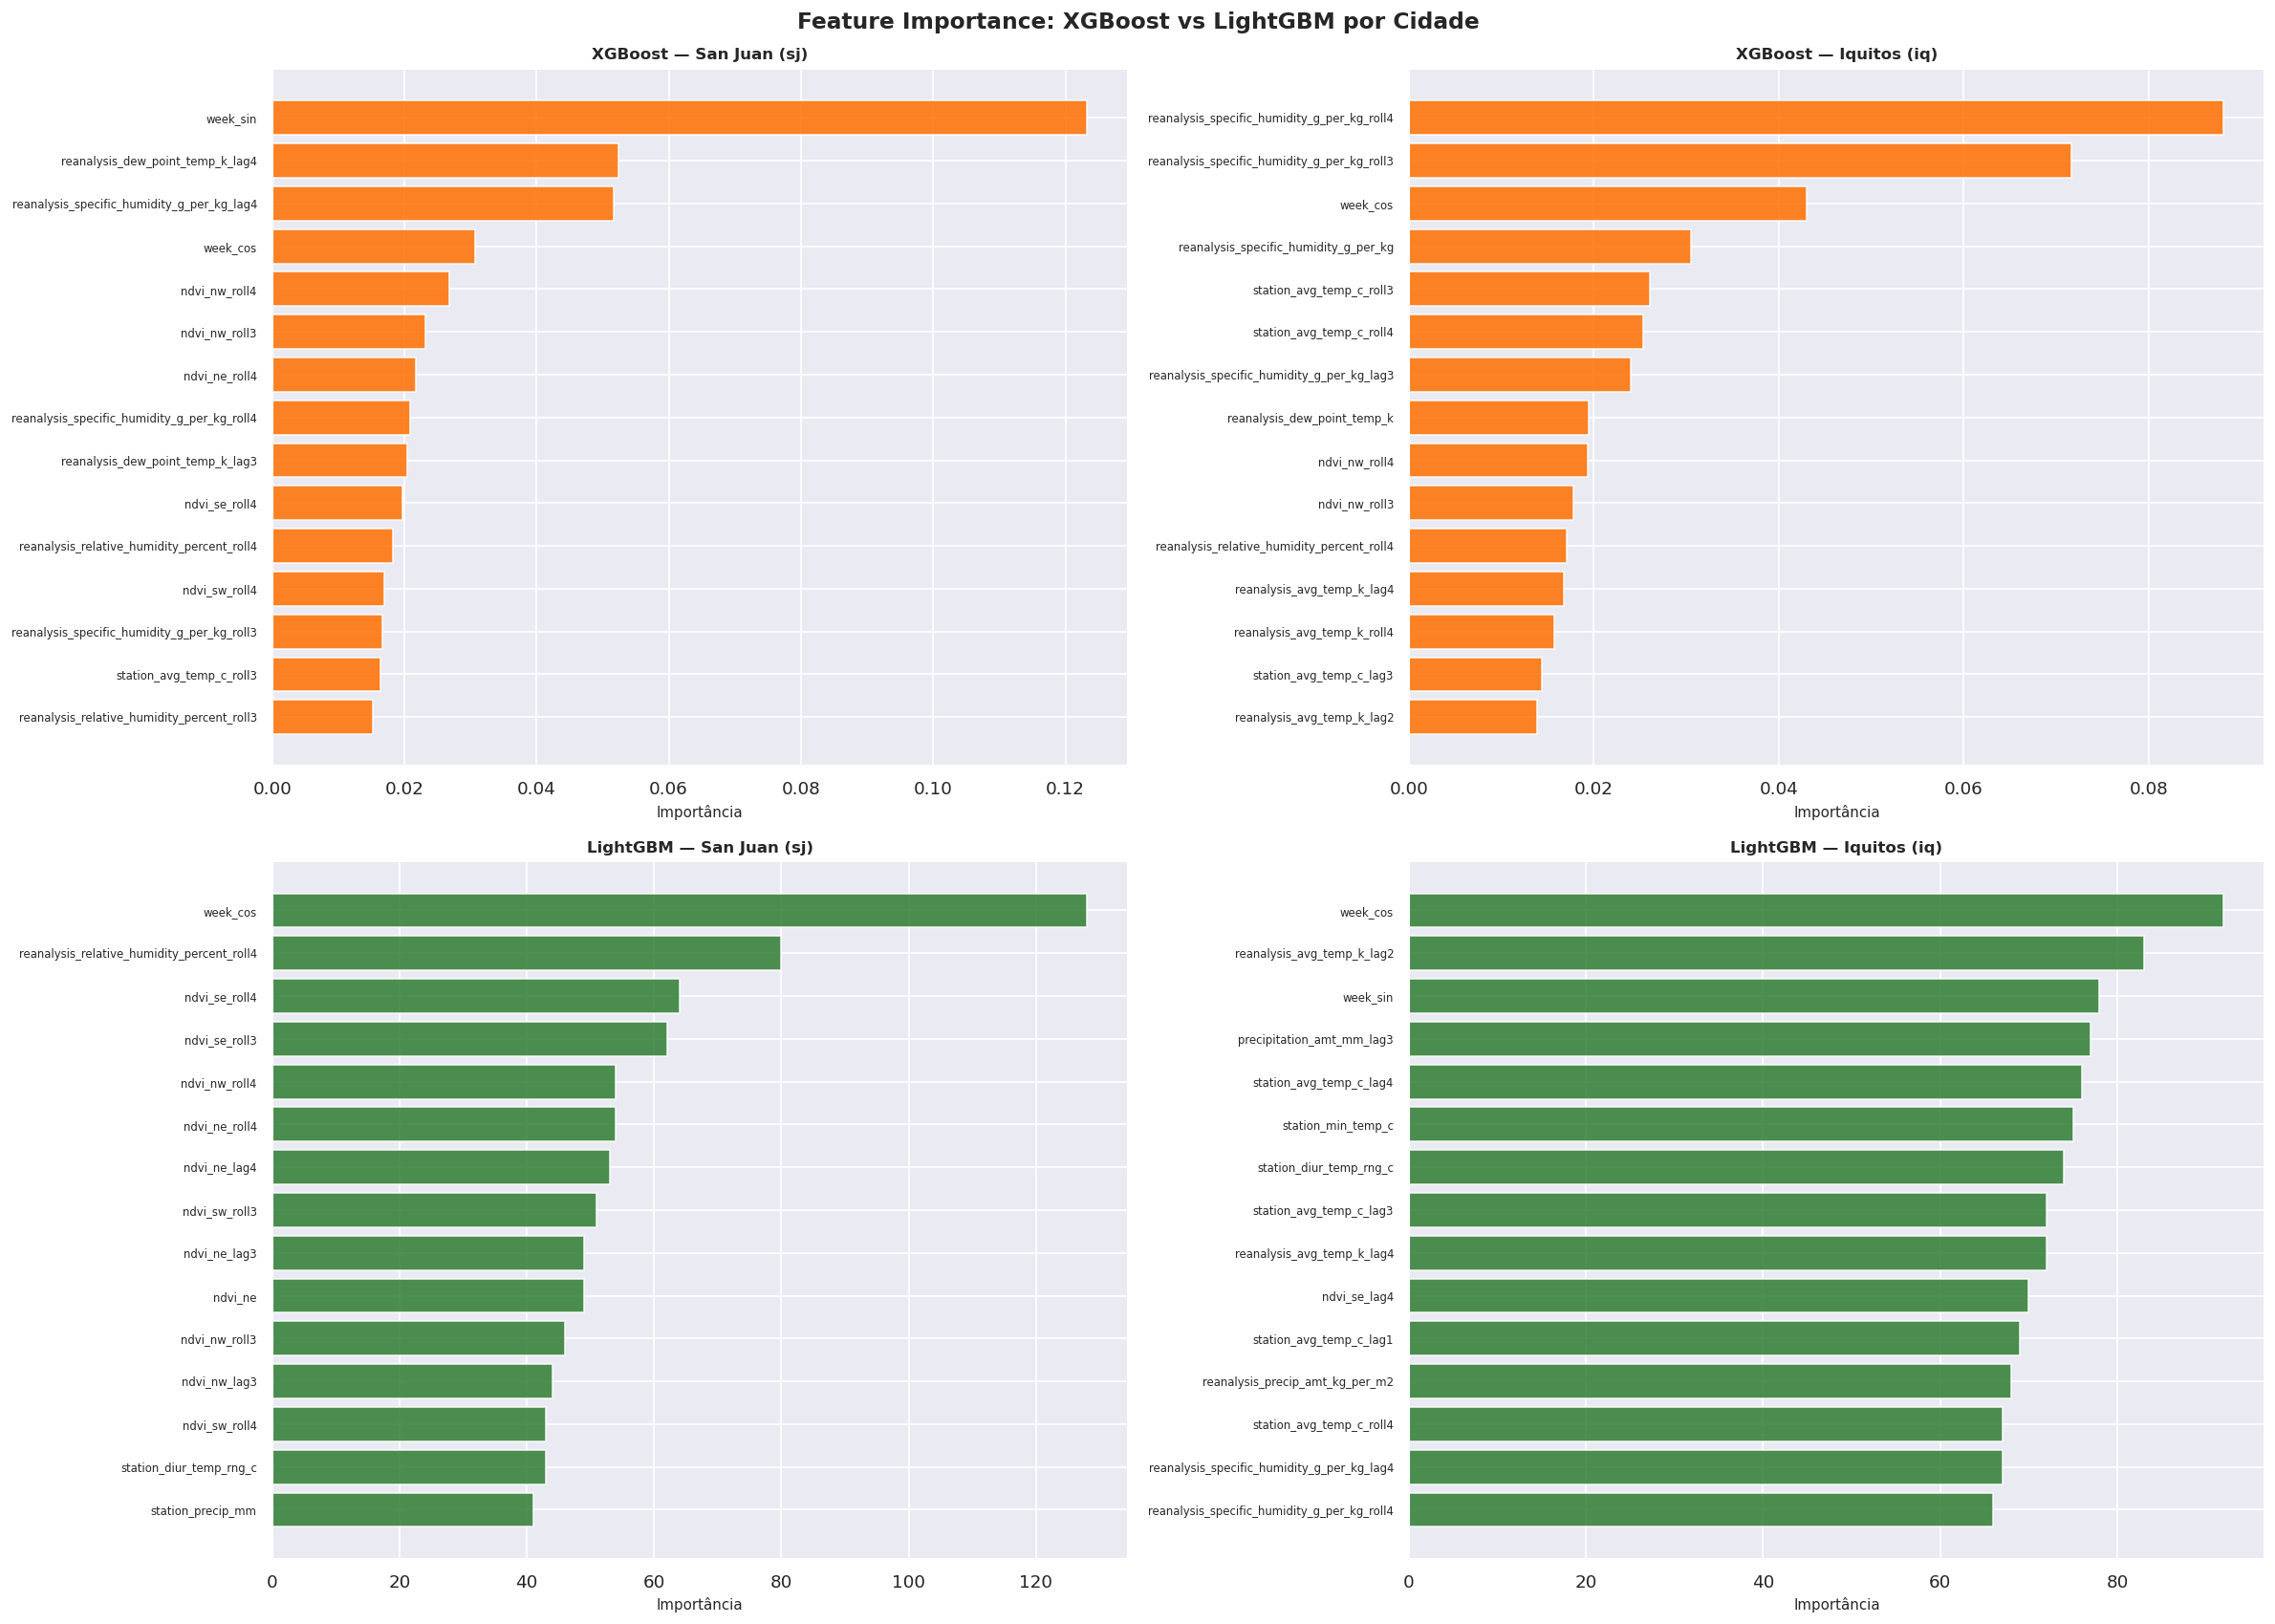

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

modelos_plot = [
    (xgb_sj, 'XGBoost', 'San Juan (sj)', '#FF6F00', axes[0, 0]),
    (xgb_iq, 'XGBoost', 'Iquitos (iq)',  '#FF6F00', axes[0, 1]),
    (lgbm_sj,'LightGBM','San Juan (sj)', '#2E7D32', axes[1, 0]),
    (lgbm_iq,'LightGBM','Iquitos (iq)',  '#2E7D32', axes[1, 1]),
]

for modelo, nome, cidade, cor, ax in modelos_plot:
    # Re-treinar no dataset completo para obter importâncias finais
    modelo.fit(
        train_sj[feat_cols].values if 'San Juan' in cidade else train_iq[feat_cols].values,
        train_sj['total_cases_log'].values if 'San Juan' in cidade else train_iq['total_cases_log'].values
    )
    imps = modelo.feature_importances_
    top_n = 15
    idx = np.argsort(imps)[-top_n:]
    ax.barh(range(top_n), imps[idx], color=cor, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feat_cols[i] for i in idx], fontsize=7)
    ax.set_title(f'{nome} — {cidade}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Importância', fontsize=9)

plt.tight_layout()
plt.suptitle('Feature Importance: XGBoost vs LightGBM por Cidade',
             y=1.01, fontsize=14, fontweight='bold')
plt.show()


### 5. Tabela Comparativa Final


── Tabela Comparativa — Todos os Modelos ──
             Modelo    MAE SJ    MAE IQ Tempo  MAE Médio
Random Forest (NB3) 22.000000  8.500000    --      15.25
            SARIMAX 23.017099  7.626708  208s      15.32
            XGBoost 25.887517  6.807380   27s      16.35
           LightGBM 26.408959  6.827609   11s      16.62
Neg. Binomial (NB3) 25.000000 10.000000    --      17.50

Referência competitiva: MAE < 25 (agregado sj + iq)


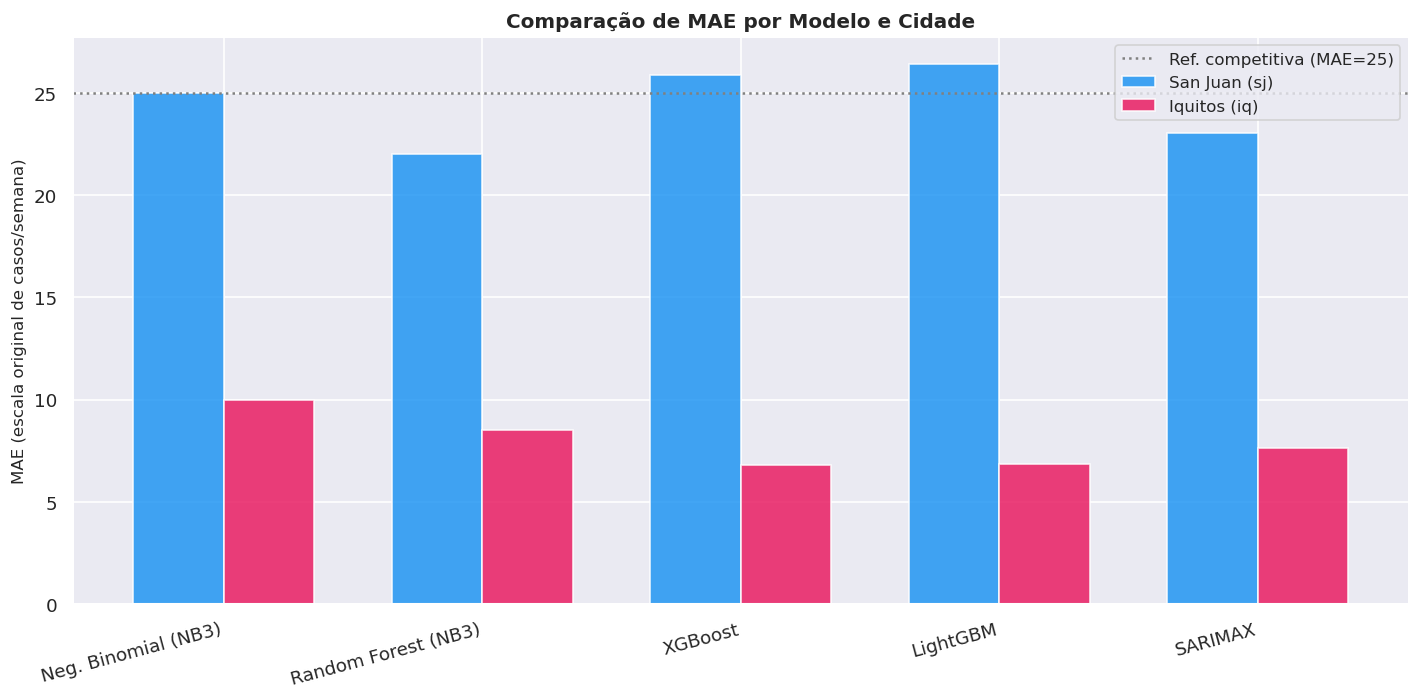


Modelos guardados em database/models/


In [6]:
# Carregar resultados do Notebook 3 (se disponíveis) ou usar valores estimados
try:
    # Tentar carregar — se o NB3 foi executado, estão em memória
    # Como estamos num notebook separado, usamos valores aproximados do benchmark
    # (substitua pelos valores reais do NB3 quando executar sequencialmente)
    mae_nb_sj_m   = 25.0   # placeholder — substituir pelo valor real do NB3
    mae_nb_iq_m   = 10.0
    mae_rf_sj_m   = 22.0
    mae_rf_iq_m   = 8.5
except:
    mae_nb_sj_m, mae_nb_iq_m = 25.0, 10.0
    mae_rf_sj_m, mae_rf_iq_m = 22.0, 8.5

# Tabela final
linhas = [
    ('Neg. Binomial (NB3)',  mae_nb_sj_m,    mae_nb_iq_m,    '--'),
    ('Random Forest (NB3)',  mae_rf_sj_m,    mae_rf_iq_m,    '--'),
    ('XGBoost',              mae_xgb_sj_m,   mae_xgb_iq_m,   f'{t_xgb:.0f}s'),
    ('LightGBM',             mae_lgbm_sj_m,  mae_lgbm_iq_m,  f'{t_lgbm:.0f}s'),
    ('SARIMAX',              mae_sar_sj_m,   mae_sar_iq_m,   f'{t_sar:.0f}s'),
]

df_comp = pd.DataFrame(linhas, columns=['Modelo', 'MAE SJ', 'MAE IQ', 'Tempo'])
df_comp['MAE Médio'] = df_comp.apply(
    lambda r: round((r['MAE SJ'] + r['MAE IQ']) / 2, 2)
    if isinstance(r['MAE SJ'], float) else '--', axis=1
)
df_comp = df_comp.sort_values('MAE Médio')
print("── Tabela Comparativa — Todos os Modelos ──")
print(df_comp.to_string(index=False))
print("\nReferência competitiva: MAE < 25 (agregado sj + iq)")

# Visualização dos MAEs
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
x = np.arange(len(linhas))
width = 0.35

maes_sj = [r[1] for r in linhas if isinstance(r[1], float)]
maes_iq = [r[2] for r in linhas if isinstance(r[2], float)]
nomes   = [r[0] for r in linhas]

bars_sj = ax.bar(x - width/2, maes_sj, width, label='San Juan (sj)', color='#2196F3', alpha=0.85)
bars_iq = ax.bar(x + width/2, maes_iq, width, label='Iquitos (iq)',  color='#E91E63', alpha=0.85)

ax.axhline(25, color='grey', linestyle=':', linewidth=1.5, label='Ref. competitiva (MAE=25)')
ax.set_xticks(x)
ax.set_xticklabels(nomes, rotation=15, ha='right')
ax.set_title('Comparação de MAE por Modelo e Cidade', fontweight='bold')
ax.set_ylabel('MAE (escala original de casos/semana)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Guardar melhores modelos para o Notebook 5
import pickle, os
os.makedirs('database/models', exist_ok=True)
with open('database/models/xgb_sj.pkl', 'wb') as f: pickle.dump(xgb_sj, f)
with open('database/models/xgb_iq.pkl', 'wb') as f: pickle.dump(xgb_iq, f)
with open('database/models/lgbm_sj.pkl', 'wb') as f: pickle.dump(lgbm_sj, f)
with open('database/models/lgbm_iq.pkl', 'wb') as f: pickle.dump(lgbm_iq, f)
print("\nModelos guardados em database/models/")


## ── Submissão SARIMAX — treino no dataset completo + forecast para o teste ──

In [7]:
# ── Submissão SARIMAX — treino no dataset completo + forecast para o teste ──

def sarimax_submission(train_df, test_df, cidade):
    """
    Treina SARIMAX no dataset de treino completo e gera previsões para o período de teste.
    Devolve um DataFrame com city, year, weekofyear, total_cases.
    """
    y_train  = train_df['total_cases_log'].values
    X_train  = train_df[sarimax_features].values
    X_test   = test_df[sarimax_features].values
    n_steps  = len(test_df)

    print(f"  [{cidade}] A treinar SARIMAX em {len(y_train)} semanas "
          f"→ forecast {n_steps} semanas...")

    modelo = sm.tsa.SARIMAX(
        y_train, exog=X_train,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 1, 52),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = modelo.fit(disp=False, maxiter=300)

    preds_log  = res.forecast(steps=n_steps, exog=X_test)
    preds_orig = np.maximum(np.round(np.expm1(preds_log)).astype(int), 0)

    out = test_df[['city', 'year', 'weekofyear']].copy()
    out['total_cases'] = preds_orig
    print(f"  [{cidade}] forecast: min={preds_orig.min()}  "
          f"max={preds_orig.max()}  média={preds_orig.mean():.1f}")
    return out


print("── Submission SARIMAX ──\n")
sub_sj = sarimax_submission(train_sj, test_sj, 'SJ')
sub_iq = sarimax_submission(train_iq, test_iq, 'IQ')

submission = pd.concat([sub_sj, sub_iq], ignore_index=True)

# Validar contra o formato da competição
fmt = pd.read_csv('database/submission_format.csv')
assert list(submission.columns) == list(fmt.columns), "Colunas não coincidem com submission_format"
assert len(submission) == len(fmt), f"Nº de linhas errado: {len(submission)} vs {len(fmt)}"
assert (submission['city']        == fmt['city']).all(),        "city fora de ordem"
assert (submission['year']        == fmt['year']).all(),        "year fora de ordem"
assert (submission['weekofyear']  == fmt['weekofyear']).all(),  "weekofyear fora de ordem"

os.makedirs('database/submissions', exist_ok=True)
submission.to_csv('database/submissions/submission_sarimax.csv', index=False)

print(f"\nFicheiro gerado: database/submissions/submission_sarimax.csv")
print(f"Linhas: {len(submission)}  (SJ={len(sub_sj)}, IQ={len(sub_iq)})")
print(submission.head(8).to_string(index=False))


── Submission SARIMAX ──

  [SJ] A treinar SARIMAX em 932 semanas → forecast 260 semanas...
  [SJ] forecast: min=3  max=43  média=19.6
  [IQ] A treinar SARIMAX em 516 semanas → forecast 156 semanas...
  [IQ] forecast: min=2  max=12  média=5.9

Ficheiro gerado: database/submissions/submission_sarimax.csv
Linhas: 416  (SJ=260, IQ=156)
city  year  weekofyear  total_cases
  sj  2008          18            3
  sj  2008          19            4
  sj  2008          20            4
  sj  2008          21            4
  sj  2008          22            5
  sj  2008          23            5
  sj  2008          24            5
  sj  2008          25            6


## ── Submission Best-Per-City ──────────────────────────────────────────────
### Usa o modelo com menor MAE de CV para SJ e o modelo com menor MAE de CV para IQ.
### Ambos são retreinados no dataset de treino completo antes de prever o teste.


In [8]:
# ── Submission Best-Per-City ──────────────────────────────────────────────
# Usa o modelo com menor MAE de CV para SJ e o modelo com menor MAE de CV para IQ.
# Ambos são retreinados no dataset de treino completo antes de prever o teste.

mae_por_modelo = {
    'XGBoost':  {'SJ': mae_xgb_sj_m,  'IQ': mae_xgb_iq_m},
    'LightGBM': {'SJ': mae_lgbm_sj_m, 'IQ': mae_lgbm_iq_m},
    'SARIMAX':  {'SJ': mae_sar_sj_m,  'IQ': mae_sar_iq_m},
}

best_sj = min(mae_por_modelo, key=lambda m: mae_por_modelo[m]['SJ'])
best_iq = min(mae_por_modelo, key=lambda m: mae_por_modelo[m]['IQ'])

print(f"Melhor modelo SJ → {best_sj}  (MAE CV = {mae_por_modelo[best_sj]['SJ']:.2f})")
print(f"Melhor modelo IQ → {best_iq}  (MAE CV = {mae_por_modelo[best_iq]['IQ']:.2f})\n")


def predict_full(model_name, train_df, test_df, cidade):
    """Retreina no dataset completo e prevê o teste."""
    if model_name == 'SARIMAX':
        return sarimax_submission(train_df, test_df, cidade)

    base = {'XGBoost': xgb_sj, 'LightGBM': lgbm_sj}[model_name] if cidade == 'SJ' \
      else {'XGBoost': xgb_iq, 'LightGBM': lgbm_iq}[model_name]

    m = clone(base)
    m.fit(train_df[feat_cols].values, train_df['total_cases_log'].values)
    preds = np.maximum(np.round(np.expm1(m.predict(test_df[feat_cols].values))).astype(int), 0)

    out = test_df[['city', 'year', 'weekofyear']].copy()
    out['total_cases'] = preds
    print(f"  [{cidade}] {model_name}: min={preds.min()}  max={preds.max()}  média={preds.mean():.1f}")
    return out


sub_sj_best = predict_full(best_sj, train_sj, test_sj, 'SJ')
sub_iq_best = predict_full(best_iq, train_iq, test_iq, 'IQ')

submission_best = pd.concat([sub_sj_best, sub_iq_best], ignore_index=True)

fmt = pd.read_csv('database/submission_format.csv')
assert list(submission_best.columns) == list(fmt.columns)
assert len(submission_best) == len(fmt)
assert (submission_best['city']       == fmt['city']).all()
assert (submission_best['year']       == fmt['year']).all()
assert (submission_best['weekofyear'] == fmt['weekofyear']).all()

submission_best.to_csv('database/submissions/submission_best_per_city.csv', index=False)
print(f"\nFicheiro gerado: database/submissions/submission_best_per_city.csv")
print(f"  SJ → {best_sj}   IQ → {best_iq}")
print(f"  Linhas: {len(submission_best)}")
print(submission_best.head(8).to_string(index=False))


Melhor modelo SJ → SARIMAX  (MAE CV = 23.02)
Melhor modelo IQ → XGBoost  (MAE CV = 6.81)

  [SJ] A treinar SARIMAX em 932 semanas → forecast 260 semanas...
  [SJ] forecast: min=3  max=43  média=19.6
  [IQ] XGBoost: min=1  max=14  média=4.8

Ficheiro gerado: database/submissions/submission_best_per_city.csv
  SJ → SARIMAX   IQ → XGBoost
  Linhas: 416
city  year  weekofyear  total_cases
  sj  2008          18            3
  sj  2008          19            4
  sj  2008          20            4
  sj  2008          21            4
  sj  2008          22            5
  sj  2008          23            5
  sj  2008          24            5
  sj  2008          25            6
